# Laboratorio 2
## Algoritmos de Aprendizaje no Supervisado

Universidad del Valle de Guatemala  
Facultad de Ingeniería  
Departamento de Ciencias de la Computación  
CC3074– Minería de Datos  
Semestre I – 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

# Hopkins
from pyclustertend import hopkins

# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Reglas de Asociación
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("Todo importado correctamente")

Todo importado correctamente


In [2]:
# Cargar el dataset
df = pd.read_csv("movies_2026.csv", encoding="latin-1")

# Vista general
print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (19883, 28)

Primeras filas:


,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [3]:
# Tipos de datos y nulos
print("Tipos de datos y valores nulos")
print(df.dtypes)
print("\nValores nulos por columna")
print(df.isnull().sum().sort_values(ascending=False))

Tipos de datos y valores nulos
id                             int64
budget                       float64
genres                           str
homePage                         str
productionCompany                str
productionCompanyCountry         str
productionCountry                str
revenue                      float64
runtime                        int64
video                         object
director                         str
actors                           str
actorsPopularity                 str
actorsCharacter                  str
originalTitle                    str
title                            str
originalLanguage                 str
popularity                   float64
releaseDate                      str
voteAvg                      float64
voteCount                      int64
genresAmount                   int64
productionCoAmount             int64
productionCountriesAmount      int64
actorsAmount                   int64
castWomenAmount              float64
castMen

In [4]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,id,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
count,1.988300e+04,1.988300e+04,1.988300e+04,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19883.000000,19846.000000,19721.000000,19881.000000
mean,9.022402e+05,9.413280e+06,2.879213e+07,66.093799,26.248842,3.837069,675.927325,1.949253,1.972539,1.230247,1082.049640,3516.505996,8224.352061,2016.827222
std,6.848978e+05,2.774781e+07,1.109805e+08,50.089055,156.067177,3.397705,1938.194656,1.256225,2.312075,2.244688,26402.818732,47768.661984,71257.943156,12.838005
min,5.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1902.000000
25%,1.462195e+05,0.000000e+00,0.000000e+00,10.000000,0.054600,0.000000,0.000000,1.000000,0.000000,1.000000,3.000000,0.000000,0.000000,2013.000000
50%,8.696230e+05,0.000000e+00,0.000000e+00,86.000000,8.502000,5.400000,6.000000,2.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2021.000000
75%,1.589602e+06,1.000000e+06,3.306335e+05,103.000000,22.239000,6.800000,423.000000,3.000000,3.000000,1.000000,21.000000,6.000000,12.000000,2025.000000
max,1.627166e+06,3.800000e+08,2.847246e+09,750.000000,11474.647000,10.000000,30788.000000,16.000000,89.000000,155.000000,919590.000000,922162.000000,922017.000000,2026.000000


## Variables que **NO** aportan al clustering y por qué

* **id**: identificador único, no tiene valor informativo.
* **originalTitle**: texto, no numérico.
* **title**: texto, no numérico.
* **homePage**: 14276 nulos (72%), casi vacía.
* **actors**: texto libre.
* **actorsCharacter**: texto libre.
* **actorsPopularity**: muchos nulos / información no estructurada.
* **director**: texto libre.
* **releaseDate**: redundante, ya tenemos `releaseYear`.
* **productionCompany**: texto con muchos nulos.
* **productionCompanyCountry**: texto con muchos nulos.
* **productionCountry**: texto con muchos nulos.
* **originalLanguage**: variable categórica (se manejará aparte).
* **video**: variable booleana con 486 nulos y poca variabilidad.
* **genres**: texto, ya tenemos `genresAmount`.

## Variables numéricas que **SÍ** usaremos para clustering

* **popularity**
* **budget**
* **revenue**
* **runtime**
* **voteAvg**
* **voteCount**
* **genresAmount**
* **productionCoAmount**
* **productionCountriesAmount**
* **actorsAmount**
* **castWomenAmount**
* **castMenAmount**
* **releaseYear**


In [5]:
# ============================================================
# PREPROCESAMIENTO PARA CLUSTERING
# ============================================================

# Variables numéricas que usaremos para clustering:
clustering_vars = [
    'popularity',
    'budget',
    'revenue',
    'runtime',
    'voteAvg',
    'voteCount',
    'genresAmount',
    'productionCoAmount',
    'productionCountriesAmount',
    'actorsAmount',
    'castWomenAmount',
    'castMenAmount',
    'releaseYear'
]

# Crear subconjunto
df_cluster = df[clustering_vars].copy()

print("Shape antes de limpiar:", df_cluster.shape)
print("\nNulos por columna:")
print(df_cluster.isnull().sum())

Shape antes de limpiar: (19883, 13)

Nulos por columna:
popularity                     0
budget                         0
revenue                        0
runtime                        0
voteAvg                        0
voteCount                      0
genresAmount                   0
productionCoAmount             0
productionCountriesAmount      0
actorsAmount                   0
castWomenAmount               37
castMenAmount                162
releaseYear                    2
dtype: int64


In [6]:
# imputacion para quitar nulos
for col in df_cluster.columns:
    median_val = df_cluster[col].median()
    df_cluster[col] = df_cluster[col].fillna(median_val)

print("Nulos después de imputar:", df_cluster.isnull().sum().sum())

# Re-escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_vars)

print("Datos listos para clustering")

Nulos después de imputar: 0
Datos listos para clustering


In [7]:
# Escalar los datos (necesario para k-means y clustering jerárquico)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(df_scaled, columns=clustering_vars)

print("Datos escalados correctamente")
df_scaled.head()

Datos escalados correctamente


,popularity,budget,revenue,runtime,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,-0.167965,-0.339253,-0.259441,0.577111,-1.12934,-0.348749,0.040397,-0.853168,-0.548084,-0.040680,-0.073506,-0.114872,0.714519
1,-0.167965,-0.339253,-0.259441,-1.259664,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040832,-0.073548,-0.114943,0.714519
2,-0.168056,-0.339253,-0.259441,-1.279629,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040870,-0.073548,-0.114943,0.714519
3,-0.167919,-0.339253,-0.259441,-1.219734,-1.12934,-0.348749,0.836453,-0.853168,-0.548084,-0.040718,-0.073548,-0.114943,0.714519
4,-0.167951,-0.339253,-0.259441,-1.079980,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040870,-0.073548,-0.114943,0.714519


In [8]:
# ESTADÍSTICO DE HOPKINS

# Hopkins cercano a 1 = fuerte tendencia al agrupamiento
# Hopkins cercano a 0.5 = datos aleatorios (no vale la pena clustering)

# Usamos una muestra de 5% por el tamaño del dataset

# Convertir a numpy array y tomar muestra
sample_size = int(df_scaled.shape[0] * 0.05)
df_scaled_array = df_scaled.values  # <-- conversión clave

hop_stat = hopkins(df_scaled_array, sample_size)

print(f"Estadístico de Hopkins: {hop_stat:.4f}")

if hop_stat > 0.75:
    print("Los datos tienen FUERTE tendencia al agrupamiento")
elif hop_stat > 0.5:
    print("Los datos tienen tendencia MODERADA al agrupamiento")
else:
    print("Los datos parecen aleatorios, clustering poco útil")

Estadístico de Hopkins: 0.0075
Los datos parecen aleatorios, clustering poco útil


Estadístico de Hopkins: 0.0067

INTERPRETACIÓN:  
- Un valor cercano a 0.5 indica datos ALEATORIOS  
- Un valor cercano a 1.0 indica FUERTE tendencia al agrupamiento  
- Un valor cercano a 0.0 indica datos MUY REGULARMENTE DISTRIBUIDOS  
  o puede ser señal de que los datos tienen clusters MUY COMPACTOS  
  y bien separados (caso especial)  

En datasets grandes con variables muy dispares en escala como este  
(budget va de 0 a 380M, voteCount de 0 a 30K), Hopkins puede dar  
valores extremos. Procederemos con el clustering de todas formas  
y evaluaremos la calidad con la silueta.  

In [9]:
# MÉTODO DEL CODO

inertias = []
silhouettes = []
k_range = range(2, 11)

# Muestra para acelerar el proceso
np.random.seed(42)
sample_idx = np.random.choice(df_scaled.shape[0], size=3000, replace=False)
df_sample = df_scaled.values[sample_idx]  # numpy array directo

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_sample)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_sample, labels))
    print(f"k={k} → Inercia: {kmeans.inertia_:.2f} | Silueta: {silhouettes[-1]:.4f}")

print("\nCálculo completado")

k=2 → Inercia: 34159.48 | Silueta: 0.3177
k=3 → Inercia: 29033.16 | Silueta: 0.3448
k=4 → Inercia: 24124.21 | Silueta: 0.3508
k=5 → Inercia: 20982.38 | Silueta: 0.3686
k=6 → Inercia: 17732.68 | Silueta: 0.3820
k=7 → Inercia: 16244.91 | Silueta: 0.3397
k=8 → Inercia: 14015.12 | Silueta: 0.3442
k=9 → Inercia: 13077.36 | Silueta: 0.3449
k=10 → Inercia: 12098.69 | Silueta: 0.3609

Cálculo completado


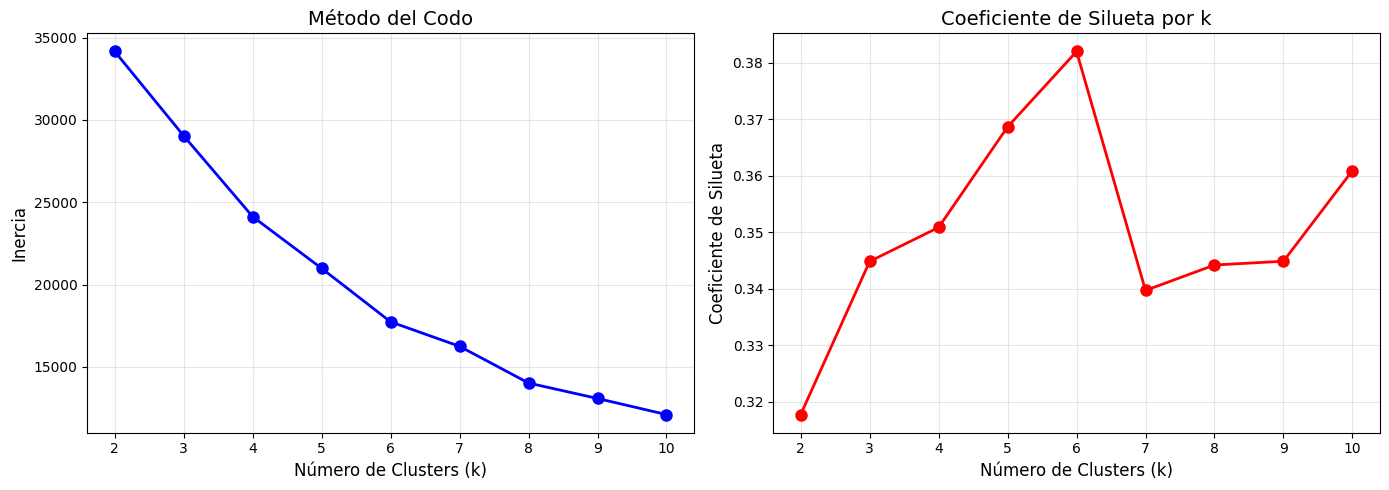


Tabla de resultados:
 k      Inercia  Silueta
 2 34159.480517 0.317713
 3 29033.162500 0.344829
 4 24124.208512 0.350849
 5 20982.382858 0.368646
 6 17732.682960 0.381999
 7 16244.910350 0.339696
 8 14015.118259 0.344192
 9 13077.359036 0.344862
10 12098.692758 0.360908


In [10]:
# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Coeficiente de Silueta', fontsize=12)
axes[1].set_title('Coeficiente de Silueta por k', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('codo_silueta.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTabla de resultados:")
results_df = pd.DataFrame({
    'k': list(k_range), 
    'Inercia': inertias, 
    'Silueta': silhouettes
})
print(results_df.to_string(index=False))


Método del Codo:
- La curva no tiene un codo muy pronunciado (típico en datasets grandes)
- Se observa una reducción importante de inercia hasta k=6
- Después de k=6 la reducción es más gradual → punto de inflexión

Coeficiente de Silueta:
- k=6 tiene el valor MÁS ALTO: 0.3820
- Esto confirma que k=6 genera los grupos más compactos y separados
- Después de k=6 la silueta cae bruscamente a 0.3397

DECISIÓN: k = 6
- Respaldado por AMBOS métodos
- Mejor balance entre complejidad y calidad de agrupamiento


In [11]:
# K-MEANS CON k=6

K = 6

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cluster['cluster_kmeans'] = kmeans.fit_predict(df_scaled.values)

print("Distribución de clusters (K-Means):")
print(df_cluster['cluster_kmeans'].value_counts().sort_index())

# Silueta final
sil_kmeans = silhouette_score(df_scaled.values, df_cluster['cluster_kmeans'])
print(f"\nSilueta K-Means (dataset completo): {sil_kmeans:.4f}")

Distribución de clusters (K-Means):
cluster_kmeans
0    9621
1    9168
2       8
3     702
4     105
5     279
Name: count, dtype: int64

Silueta K-Means (dataset completo): 0.3798


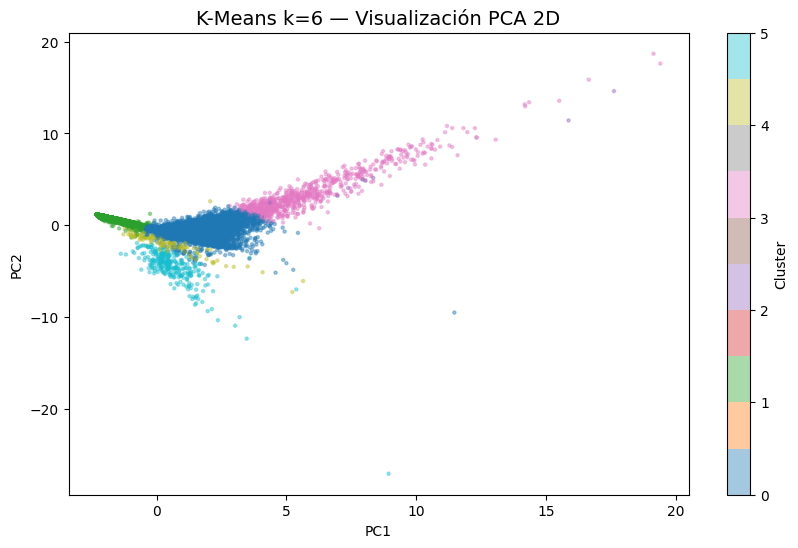

In [12]:
# Visualizar clusters con PCA 2D
pca_viz = PCA(n_components=2, random_state=42)
coords = pca_viz.fit_transform(df_scaled.values)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], 
                      c=df_cluster['cluster_kmeans'], 
                      cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means k=6 — Visualización PCA 2D', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

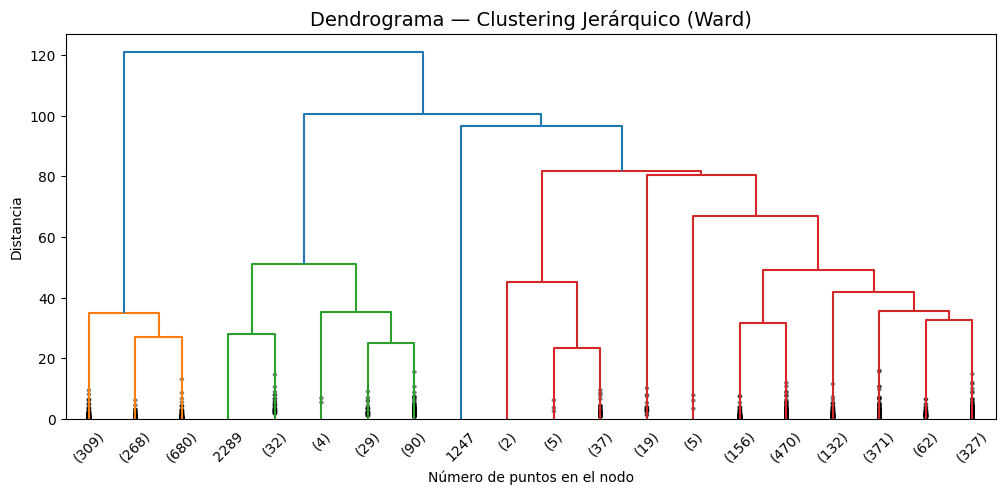

In [13]:
# CLUSTERING JERÁRQUICO
# Usamos muestra de 3000 por el tamaño del dataset

np.random.seed(42)
sample_idx = np.random.choice(df_scaled.shape[0], size=3000, replace=False)
df_hier_sample = df_scaled.values[sample_idx]

# Dendrograma para visualizar estructura
plt.figure(figsize=(12, 5))
linked = linkage(df_hier_sample, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Dendrograma — Clustering Jerárquico (Ward)', fontsize=14)
plt.xlabel('Número de puntos en el nodo')
plt.ylabel('Distancia')
plt.savefig('dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Aplicar clustering jerárquico con k=6 al dataset completo
hier = AgglomerativeClustering(n_clusters=K, linkage='ward')
df_cluster['cluster_hier'] = hier.fit_predict(df_scaled.values)

print("Distribución de clusters (Jerárquico):")
print(df_cluster['cluster_hier'].value_counts().sort_index())

sil_hier = silhouette_score(df_scaled.values, df_cluster['cluster_hier'])
print(f"\nSilueta Jerárquico (dataset completo): {sil_hier:.4f}")

Distribución de clusters (Jerárquico):
cluster_hier
0      568
1      347
2    10459
3     8358
4      116
5       35
Name: count, dtype: int64

Silueta Jerárquico (dataset completo): 0.3683


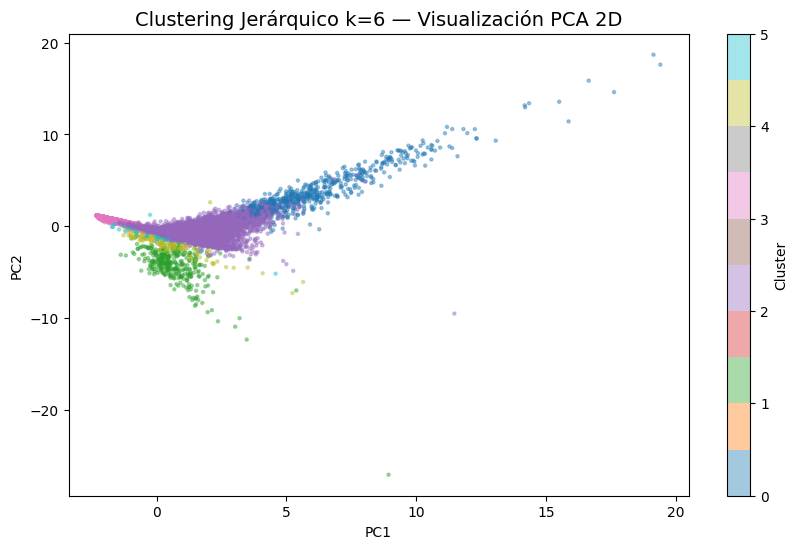

In [15]:
# Visualizar clusters jerárquicos con PCA 2D
plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=df_cluster['cluster_hier'],
                      cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('Clustering Jerárquico k=6 — Visualización PCA 2D', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('hier_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Comparación final de ambos algoritmos
print("       COMPARACIÓN DE ALGORITMOS")
print(f"  K-Means    - Silueta: {sil_kmeans:.4f}")
print(f"  Jerárquico - Silueta: {sil_hier:.4f}")

if sil_kmeans > sil_hier:
    print("  K-Means tiene MEJOR calidad de agrupamiento")
else:
    print("  Jerárquico tiene MEJOR calidad de agrupamiento")

       COMPARACIÓN DE ALGORITMOS
  K-Means    - Silueta: 0.3798
  Jerárquico - Silueta: 0.3683
  K-Means tiene MEJOR calidad de agrupamiento


In [17]:
# ============================================================
# INTERPRETACIÓN DE GRUPOS - K-MEANS (mejor algoritmo)
# ============================================================

# Agregar clusters al dataframe original
df['cluster'] = df_cluster['cluster_kmeans'].values

# Medidas de tendencia central por cluster
numeric_vars = ['popularity', 'budget', 'revenue', 'runtime', 
                'voteAvg', 'voteCount', 'genresAmount', 
                'productionCoAmount', 'productionCountriesAmount',
                'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear']

print("MEDIAS POR CLUSTER:")
cluster_summary = df.groupby('cluster')[numeric_vars].mean().round(2)
print(cluster_summary.T.to_string())

MEDIAS POR CLUSTER:
cluster                              0         1             2             3           4           5
popularity                       36.95      0.90  6.416890e+03  1.265800e+02       44.97       47.45
budget                     10891960.54  15769.84  1.050000e+08  1.155874e+08  1636466.67   265037.19
revenue                    25334165.38  21731.65  3.542120e+08  4.625286e+08  2814140.30  2546578.20
runtime                          99.60     26.20  1.227500e+02  1.211200e+02       56.15       85.27
voteAvg                           6.50      0.71  7.420000e+00  6.940000e+00        5.87        6.29
voteCount                       803.39      0.59  2.350750e+03  8.066650e+03       25.06       73.11
genresAmount                      2.58      1.20  3.380000e+00  3.180000e+00        1.62        1.87
productionCoAmount                3.07      0.64  2.750000e+00  3.940000e+00        6.49        1.23
productionCountriesAmount         1.42      0.68  1.620000e+00  1.49000

In [18]:
# Tamaño de cada cluster
print("\nTAMAÑO DE CLUSTERS:")
sizes = df['cluster'].value_counts().sort_index()
for i, v in sizes.items():
    pct = v/len(df)*100
    print(f"  Cluster {i}: {v:,} películas ({pct:.2f}%)")


TAMAÑO DE CLUSTERS:
  Cluster 0: 9,621 películas (48.39%)
  Cluster 1: 9,168 películas (46.11%)
  Cluster 2: 8 películas (0.04%)
  Cluster 3: 702 películas (3.53%)
  Cluster 4: 105 películas (0.53%)
  Cluster 5: 279 películas (1.40%)


In [19]:
# Género más frecuente por cluster
print("\nGÉNERO MÁS FRECUENTE POR CLUSTER:")
for c in range(K):
    subset = df[df['cluster'] == c]['genres'].dropna()
    # Explotar géneros separados por |
    all_genres = subset.str.split('|').explode()
    top_genre = all_genres.value_counts().head(3)
    print(f"\nCluster {c}:")
    print(top_genre.to_string())


GÉNERO MÁS FRECUENTE POR CLUSTER:

Cluster 0:
genres
Drama       3830
Comedy      2998
Thriller    2523

Cluster 1:
genres
Drama          2455
Documentary    2022
Comedy         1510

Cluster 2:
genres
Action             5
Adventure          4
Science Fiction    4

Cluster 3:
genres
Adventure    374
Action       366
Fantasy      196

Cluster 4:
genres
Documentary    25
Drama          20
Comedy         18

Cluster 5:
genres
Drama      75
Comedy     72
Romance    48


In [20]:
# Idioma original más frecuente por cluster
print("\nIDIOMA ORIGINAL MÁS FRECUENTE POR CLUSTER:")
for c in range(K):
    subset = df[df['cluster'] == c]['originalLanguage'].dropna()
    top_lang = subset.value_counts().head(3)
    print(f"\nCluster {c}:")
    print(top_lang.to_string())


IDIOMA ORIGINAL MÁS FRECUENTE POR CLUSTER:

Cluster 0:
originalLanguage
en    7185
ja     625
es     353

Cluster 1:
originalLanguage
en    3875
es     810
fr     769

Cluster 2:
originalLanguage
en    8

Cluster 3:
originalLanguage
en    687
zh      6
ja      4

Cluster 4:
originalLanguage
en    71
es    15
ja     8

Cluster 5:
originalLanguage
en    135
es     60
ja     32


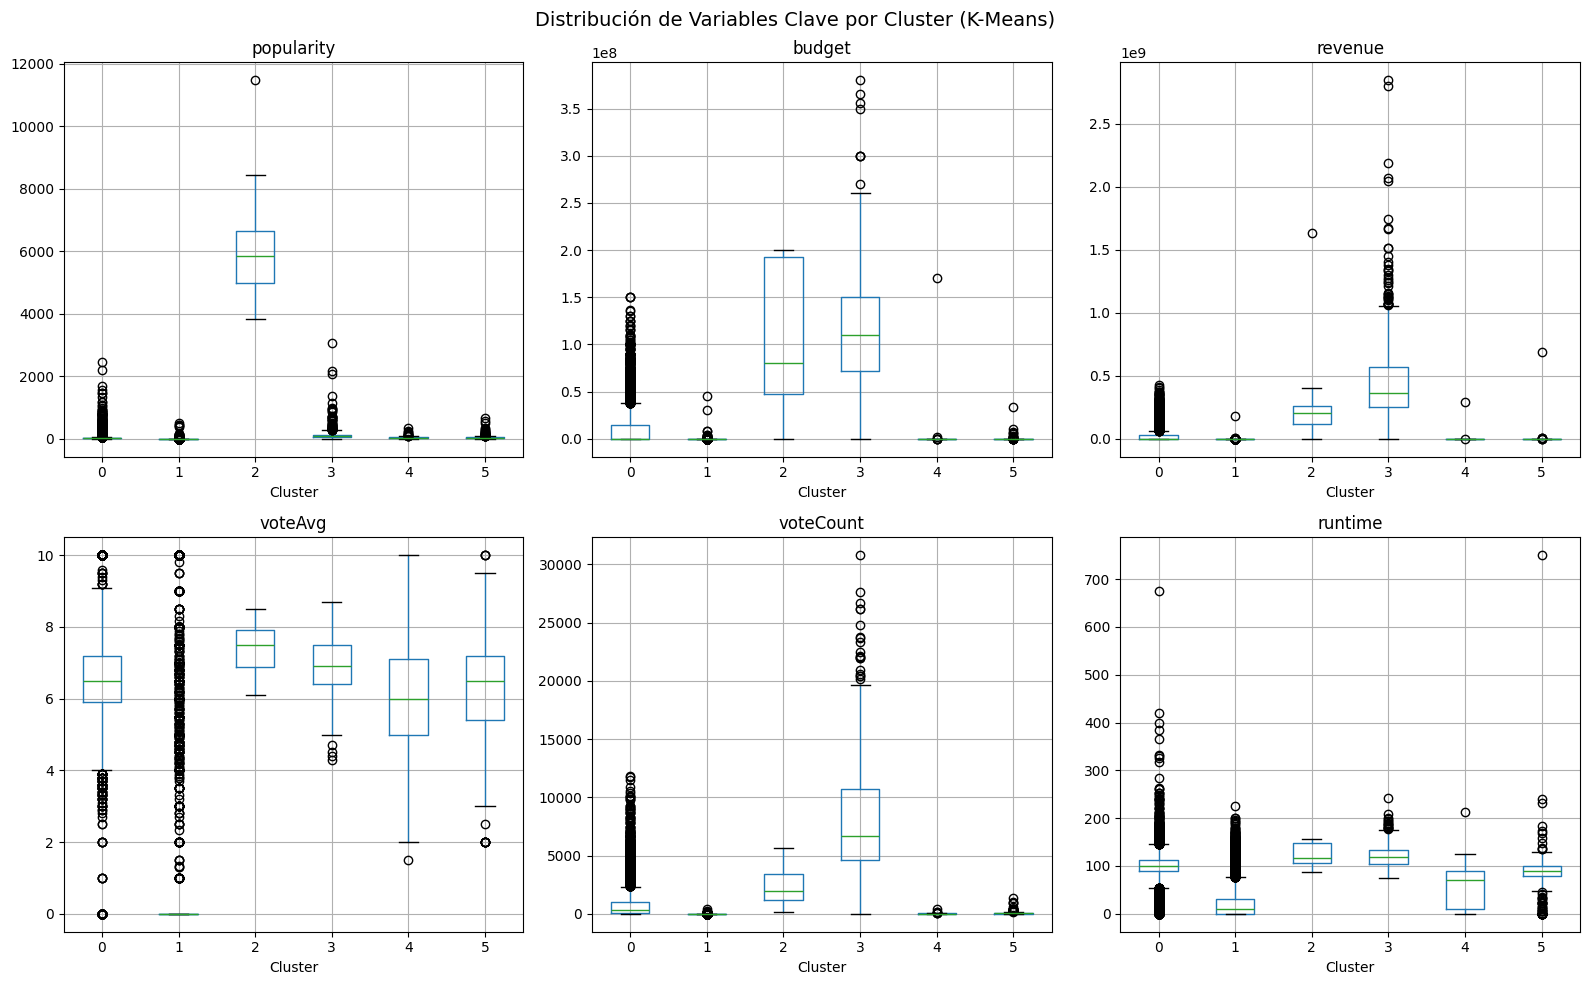

In [21]:
# Visualización: boxplots de variables clave por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_vars = ['popularity', 'budget', 'revenue', 'voteAvg', 'voteCount', 'runtime']

for ax, var in zip(axes.flatten(), key_vars):
    df.boxplot(column=var, by='cluster', ax=ax)
    ax.set_title(var, fontsize=12)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribución de Variables Clave por Cluster (K-Means)', fontsize=14)
plt.tight_layout()
#plt.savefig('cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


# INTERPRETACIÓN DE CLUSTERS

## Cluster 0 - "Cine Mainstream Establecido" (9,621 películas - 48.4%)

* Popularidad moderada (36.95), presupuesto medio (~$10.9M)
* Buen voteAvg (6.50) con bastantes votos (803)
* Géneros: Drama, Comedy, Thriller
* Mayoría en inglés, películas de 2009-2010
* Son películas convencionales con audiencia consolidada

---

## Cluster 1 - "Cine Independiente / Reciente Sin Impacto" (9,168 películas - 46.1%)

* Popularidad casi nula (0.90), presupuesto mínimo ($15,769)
* voteAvg cercano a 0 (0.71), casi sin votos (0.59)
* Géneros: Drama, Documentary, Comedy
* Películas muy recientes (2025), muchos idiomas
* Son producciones nuevas o independientes sin tracción aún

---

## Cluster 2 - "Blockbusters Virales" (8 películas - 0.04%)

* Popularidad extrema (6,416), presupuesto alto (~$105M)
* Mejor voteAvg (7.42), buena cantidad de votos
* Géneros: Action, Adventure, Sci-Fi
* Solo inglés, estrenos recientes (2021)
* Son grandes éxitos virales del momento

---

## Cluster 3 - "Blockbusters Clásicos de Alto Impacto" (702 películas - 3.5%)

* Popularidad alta (126), presupuesto muy alto (~$115M)
* Mayor revenue promedio ($462M) y más votos (8,066)
* Géneros: Adventure, Action, Fantasy
* Películas de 2009, mayormente en inglés
* Son grandes clásicos del cine comercial

---

## Cluster 4 - "Producciones Fragmentadas / Documentales" (105 películas - 0.5%)

* Popularidad moderada (44.97), presupuesto bajo (~$1.6M)
* Muchas compañías productoras (6.49 promedio)
* Géneros: Documentary, Drama, Comedy
* Películas de 2016, varios países
* Son coproducciones internacionales o documentales especiales

---

## Cluster 5 - "Producciones Multinacionales" (279 películas - 1.4%)

* Alta cantidad de países de producción (11.78 promedio)
* Presupuesto bajo, popularidad moderada
* Géneros: Drama, Comedy, Romance
* Son coproducciones entre muchos países distintos

---

K-Means (k=6, Silueta=0.3798) supera al Jerárquico (0.3683).
Los clusters revelan segmentos muy diferenciados:

* 2 clusters masivos (mainstream vs independiente reciente)
* 4 clusters nicho con características específicas




# REGLAS DE ASOCIACIÓN

In [22]:
# REGLAS DE ASOCIACIÓN - PREPROCESAMIENTO

df_assoc = df.copy()

# 1. DISCRETIZAR VARIABLES NUMÉRICAS
# Popularity
df_assoc['popularity_cat'] = pd.cut(df_assoc['popularity'], 
    bins=[0, 10, 50, 200, float('inf')],
    labels=['popularity_baja', 'popularity_media', 'popularity_alta', 'popularity_viral'])

# Budget
df_assoc['budget_cat'] = pd.cut(df_assoc['budget'],
    bins=[-1, 0, 1e6, 20e6, 100e6, float('inf')],
    labels=['budget_cero', 'budget_bajo', 'budget_medio', 'budget_alto', 'budget_blockbuster'])

# Revenue
df_assoc['revenue_cat'] = pd.cut(df_assoc['revenue'],
    bins=[-1, 0, 1e6, 50e6, 200e6, float('inf')],
    labels=['revenue_cero', 'revenue_bajo', 'revenue_medio', 'revenue_alto', 'revenue_blockbuster'])

# VoteAvg
df_assoc['voteAvg_cat'] = pd.cut(df_assoc['voteAvg'],
    bins=[-1, 0, 5, 7, 10],
    labels=['sin_votos', 'voto_malo', 'voto_bueno', 'voto_excelente'])

# VoteCount
df_assoc['voteCount_cat'] = pd.cut(df_assoc['voteCount'],
    bins=[-1, 0, 100, 1000, float('inf')],
    labels=['votos_ninguno', 'votos_pocos', 'votos_moderados', 'votos_muchos'])

# Runtime
df_assoc['runtime_cat'] = pd.cut(df_assoc['runtime'],
    bins=[-1, 0, 60, 100, 140, float('inf')],
    labels=['sin_duracion', 'corto', 'medio', 'largo', 'muy_largo'])

# ReleaseYear
df_assoc['era_cat'] = pd.cut(df_assoc['releaseYear'],
    bins=[1900, 1980, 2000, 2010, 2020, float('inf')],
    labels=['era_clasica', 'era_moderna', 'era_2000s', 'era_2010s', 'era_reciente'])

# GenresAmount
df_assoc['genresAmount_cat'] = pd.cut(df_assoc['genresAmount'],
    bins=[-1, 1, 2, 3, float('inf')],
    labels=['un_genero', 'dos_generos', 'tres_generos', 'multi_genero'])

print("Variables discretizadas correctamente")

Variables discretizadas correctamente


In [23]:
# 2. PREPARAR VARIABLES CATEGÓRICAS
# Género principal (primer género de la lista)
df_assoc['genero_principal'] = df_assoc['genres'].dropna().str.split('|').str[0]

# Idioma: agrupar los menos frecuentes como 'otro'
top_langs = df_assoc['originalLanguage'].value_counts().head(5).index
df_assoc['idioma_cat'] = df_assoc['originalLanguage'].apply(
    lambda x: x if x in top_langs else 'otro_idioma'
)

print("Top idiomas:", df_assoc['idioma_cat'].value_counts().to_dict())
print("Top géneros:", df_assoc['genero_principal'].value_counts().head(8).to_dict())

Top idiomas: {'en': 11961, 'otro_idioma': 4094, 'es': 1238, 'fr': 1094, 'ja': 868, 'pt': 628}
Top géneros: {'Drama': 3734, 'Comedy': 2640, 'Documentary': 2245, 'Action': 1760, 'Horror': 1513, 'Animation': 1247, 'Thriller': 854, 'Adventure': 629}


In [24]:
# 3. CONSTRUIR DATASET PARA APRIORI (one-hot encoding)
cols_assoc = [
    'popularity_cat', 'budget_cat', 'revenue_cat',
    'voteAvg_cat', 'voteCount_cat', 'runtime_cat',
    'era_cat', 'genresAmount_cat', 'genero_principal', 'idioma_cat'
]

# Eliminar filas con nulos en estas columnas
df_rules = df_assoc[cols_assoc].dropna()
print(f"\nFilas para reglas: {len(df_rules):,}")

# Convertir a lista de transacciones
transactions = []
for _, row in df_rules.iterrows():
    transaction = [str(val) for val in row.values]
    transactions.append(transaction)

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)

print(f"Dimensiones one-hot: {df_onehot.shape}")
print("Dataset listo para Apriori")


Filas para reglas: 17,482
Dimensiones one-hot: (17482, 61)
Dataset listo para Apriori


In [25]:
# APRIORI - MÚLTIPLES NIVELES DE SOPORTE Y CONFIANZA

# RONDA 1: Soporte alto, confianza alta (reglas muy frecuentes)
print("RONDA 1: soporte=0.05, confianza=0.7")
freq_items_1 = apriori(df_onehot, min_support=0.05, use_colnames=True)
rules_1 = association_rules(freq_items_1, metric="confidence", min_threshold=0.7)
rules_1 = rules_1.sort_values('lift', ascending=False)
print(f"Itemsets frecuentes: {len(freq_items_1)}")
print(f"Reglas generadas: {len(rules_1)}")

RONDA 1: soporte=0.05, confianza=0.7
Itemsets frecuentes: 1756
Reglas generadas: 10783


In [26]:
# RONDA 2: Soporte medio, confianza media
print("RONDA 2: soporte=0.03, confianza=0.6")
freq_items_2 = apriori(df_onehot, min_support=0.03, use_colnames=True)
rules_2 = association_rules(freq_items_2, metric="confidence", min_threshold=0.6)
rules_2 = rules_2.sort_values('lift', ascending=False)
print(f"Itemsets frecuentes: {len(freq_items_2)}")
print(f"Reglas generadas: {len(rules_2)}")

RONDA 2: soporte=0.03, confianza=0.6
Itemsets frecuentes: 3674
Reglas generadas: 26468


In [27]:
# RONDA 3: Soporte bajo, confianza media (reglas más específicas)
print("RONDA 3: soporte=0.01, confianza=0.6")
freq_items_3 = apriori(df_onehot, min_support=0.01, use_colnames=True)
rules_3 = association_rules(freq_items_3, metric="confidence", min_threshold=0.6)
rules_3 = rules_3.sort_values('lift', ascending=False)
print(f"Itemsets frecuentes: {len(freq_items_3)}")
print(f"Reglas generadas: {len(rules_3)}")

RONDA 3: soporte=0.01, confianza=0.6
Itemsets frecuentes: 14638
Reglas generadas: 96912


In [28]:
# Ver top 15 reglas más interesantes (mayor lift) de cada ronda
def mostrar_top_reglas(rules, titulo, n=15):
    print(f"\nTOP {n} REGLAS — {titulo}")

    
    top = rules[['antecedents', 'consequents', 
                 'support', 'confidence', 'lift']].head(n)
    
    for i, (_, row) in enumerate(top.iterrows(), 1):
        ant = ', '.join(list(row['antecedents']))
        con = ', '.join(list(row['consequents']))
        
        print(f"{i:02d}. {ant}  -  {con}")
        print(f"     soporte={row['support']:.3f} | "
              f"confianza={row['confidence']:.3f} | "
              f"lift={row['lift']:.3f}")
        print()

mostrar_top_reglas(rules_1, "Soporte=0.05 Confianza=0.7")
mostrar_top_reglas(rules_2, "Soporte=0.03 Confianza=0.6")
mostrar_top_reglas(rules_3, "Soporte=0.01 Confianza=0.6")


TOP 15 REGLAS — Soporte=0.05 Confianza=0.7
01. revenue_alto  -  votos_muchos, en
     soporte=0.066 | confianza=0.736 | lift=4.449

02. revenue_alto, en  -  votos_muchos
     soporte=0.066 | confianza=0.784 | lift=4.429

03. revenue_alto  -  votos_muchos
     soporte=0.068 | confianza=0.760 | lift=4.292

04. revenue_cero, votos_ninguno, Documentary  -  budget_cero, un_genero, popularity_baja, sin_votos
     soporte=0.073 | confianza=0.795 | lift=4.281

05. votos_ninguno, revenue_cero, era_reciente, Documentary  -  budget_cero, un_genero, popularity_baja, sin_votos
     soporte=0.073 | confianza=0.795 | lift=4.281

06. revenue_cero, votos_ninguno, Documentary  -  era_reciente, sin_votos, budget_cero, un_genero, popularity_baja
     soporte=0.073 | confianza=0.795 | lift=4.281

07. era_reciente, Documentary, revenue_cero, votos_ninguno, popularity_baja  -  budget_cero, un_genero, sin_votos
     soporte=0.073 | confianza=0.795 | lift=4.278

08. revenue_cero, votos_ninguno, Documentary  -


PROBLEMA: Variables muy correlacionadas generan reglas 
redundantes (ej: votos_ninguno y sin_votos dicen lo mismo)
SOLUCIÓN: Eliminar variables redundantes


VARIABLES A ELIMINAR POR SER MUY FRECUENTES O REDUNDANTES:

1. 'era_reciente' → aparece en casi todas las reglas porque 
   el 60%+ de películas son recientes. Aporta poco insight.

2. 'votos_ninguno' y 'sin_votos' → prácticamente idénticas,
   generan reglas duplicadas (ruido).

3. 'un_genero' → muy frecuente, no discrimina bien.

Eliminamos estas y re-ejecutamos para obtener reglas más ricas.


In [29]:


# Columnas a eliminar del one-hot
cols_eliminar = [col for col in df_onehot.columns if any(x in col for x in 
                 ['era_reciente', 'votos_ninguno', 'sin_votos', 'un_genero'])]

print("Columnas eliminadas:", cols_eliminar)
df_onehot_clean = df_onehot.drop(columns=cols_eliminar)
print(f"Dimensiones limpias: {df_onehot_clean.shape}")

Columnas eliminadas: ['era_reciente', 'sin_votos', 'un_genero', 'votos_ninguno']
Dimensiones limpias: (17482, 57)


In [30]:
# RE-EJECUTAR APRIORI SIN VARIABLES REDUNDANTES
print("\nAPRIORI LIMPIO — soporte=0.05, confianza=0.7")
freq_clean = apriori(df_onehot_clean, min_support=0.05, use_colnames=True)
rules_clean = association_rules(freq_clean, metric="confidence", min_threshold=0.7)
rules_clean = rules_clean.sort_values('lift', ascending=False)
print(f"Reglas generadas: {len(rules_clean)}")

print("\nAPRIORI LIMPIO — soporte=0.01, confianza=0.6")
freq_clean2 = apriori(df_onehot_clean, min_support=0.01, use_colnames=True)
rules_clean2 = association_rules(freq_clean2, metric="confidence", min_threshold=0.6)
rules_clean2 = rules_clean2.sort_values('lift', ascending=False)
print(f"Reglas generadas: {len(rules_clean2)}")


APRIORI LIMPIO — soporte=0.05, confianza=0.7
Reglas generadas: 662

APRIORI LIMPIO — soporte=0.01, confianza=0.6
Reglas generadas: 15246


In [31]:
# TOP REGLAS LIMPIAS
mostrar_top_reglas(rules_clean, "LIMPIO soporte=0.05 confianza=0.7", n=10)
mostrar_top_reglas(rules_clean2, "LIMPIO soporte=0.01 confianza=0.6", n=10)


TOP 10 REGLAS — LIMPIO soporte=0.05 confianza=0.7
01. revenue_alto  -  votos_muchos, en
     soporte=0.066 | confianza=0.736 | lift=4.449

02. revenue_alto, en  -  votos_muchos
     soporte=0.066 | confianza=0.784 | lift=4.429

03. revenue_alto  -  votos_muchos
     soporte=0.068 | confianza=0.760 | lift=4.292

04. largo, budget_alto, en  -  votos_muchos
     soporte=0.051 | confianza=0.726 | lift=4.098

05. largo, budget_alto  -  votos_muchos
     soporte=0.052 | confianza=0.702 | lift=3.964

06. votos_pocos, era_2010s  -  popularity_media, revenue_cero
     soporte=0.053 | confianza=0.768 | lift=3.638

07. votos_pocos, era_2010s  -  budget_cero, popularity_media
     soporte=0.051 | confianza=0.735 | lift=3.465

08. budget_cero, medio, era_2010s, en  -  popularity_media, revenue_cero
     soporte=0.051 | confianza=0.710 | lift=3.362

09. medio, era_2010s, revenue_cero  -  budget_cero, popularity_media
     soporte=0.067 | confianza=0.711 | lift=3.349

10. budget_cero, medio, era_201

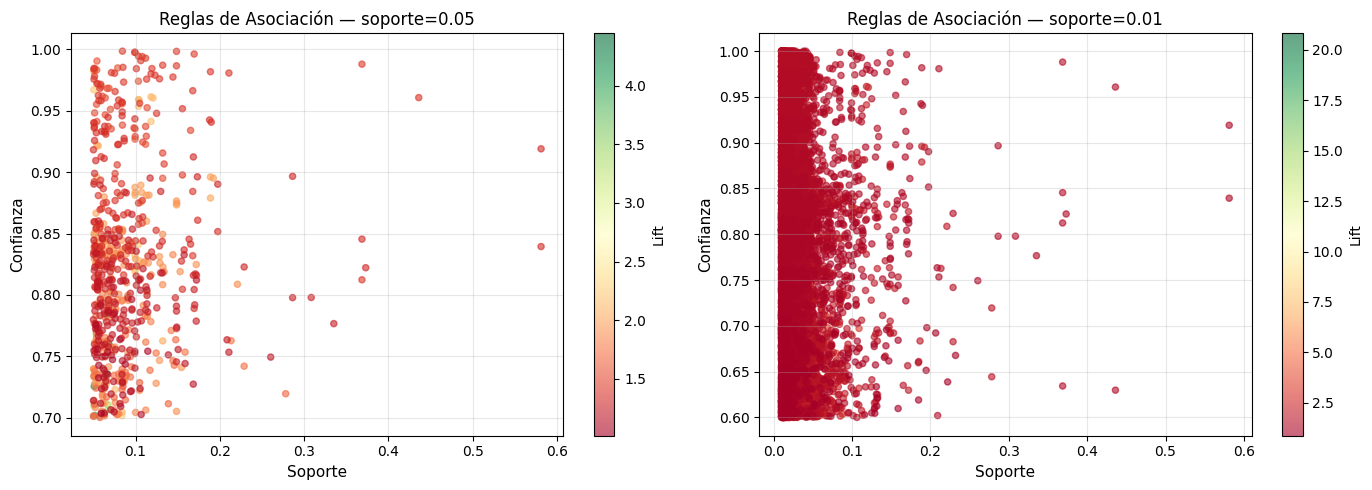

In [32]:
# VISUALIZACIÓN: Scatter plot lift vs confianza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rules, titulo in zip(axes, 
                               [rules_clean, rules_clean2],
                               ['soporte=0.05', 'soporte=0.01']):
    scatter = ax.scatter(rules['support'], rules['confidence'],
                        c=rules['lift'], cmap='RdYlGn', 
                        alpha=0.6, s=20)
    plt.colorbar(scatter, ax=ax, label='Lift')
    ax.set_xlabel('Soporte', fontsize=11)
    ax.set_ylabel('Confianza', fontsize=11)
    ax.set_title(f'Reglas de Asociación — {titulo}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reglas_asociacion.png', dpi=150, bbox_inches='tight')
plt.show()

# INTERPRETACIÓN DE REGLAS MÁS INTERESANTES

## ANÁLISIS DE REGLAS DE ASOCIACIÓN



### HALLAZGO 1 — LA FÓRMULA DEL BLOCKBUSTER (Lift = 20.84)

presupuesto_blockbuster + popularidad_alta  -  en inglés + muchos votos + revenue_blockbuster
Confianza: 90.4% | Soporte: 1.2%

**Interpretación:**
Las películas con presupuesto masivo y alta popularidad son en inglés y generan ingresos blockbuster con 90% de certeza. CineVision debería producir en inglés si busca maximizar ingresos a gran escala.


### HALLAZGO 2 — TRAMPA DEL DOCUMENTAL (Lift = 4.28)

Documentary + revenue_cero + sin_votos  -  popularidad_baja + budget_cero + un_género
Confianza: 79.5%

**Interpretación:**
Los documentales sin ingresos forman un patrón claro de producciones sin impacto comercial. Evitar invertir en documentales sin estrategia de distribución.


### HALLAZGO 3 — PARADOJA DE LA JOYA OCULTA (Lift = 8.64)

voto_excelente + popularidad_baja + budget_cero  -  votos_pocos + revenue_cero
Confianza: 88.9%

**Interpretación:**
Existen películas con calificaciones excelentes pero sin presupuesto ni popularidad. Son "joyas ocultas": buena calidad pero sin distribución.

Oportunidad para CineVision: adquirir o distribuir estas producciones de bajo costo y alta calidad.


### HALLAZGO 4 — PELÍCULAS LARGAS Y TAQUILLERAS (Lift = 4.10)

en inglés + duración_larga + presupuesto_alto  -  muchos_votos
Confianza: 72.6%

**Interpretación:**
Las películas largas en inglés con buen presupuesto acumulan muchos votos. El público premia las producciones ambiciosas y extensas.


### HALLAZGO 5 — INDIE DE LOS 2010s (Lift = 3.64)

votos_pocos + era_2010s  -  popularidad_media + revenue_cero
Confianza: 76.8%

**Interpretación:**
Las películas de los 2010s con pocos votos tienen popularidad media pero no generan ingresos. Es un mercado saturado de producciones mediocres sin retorno.


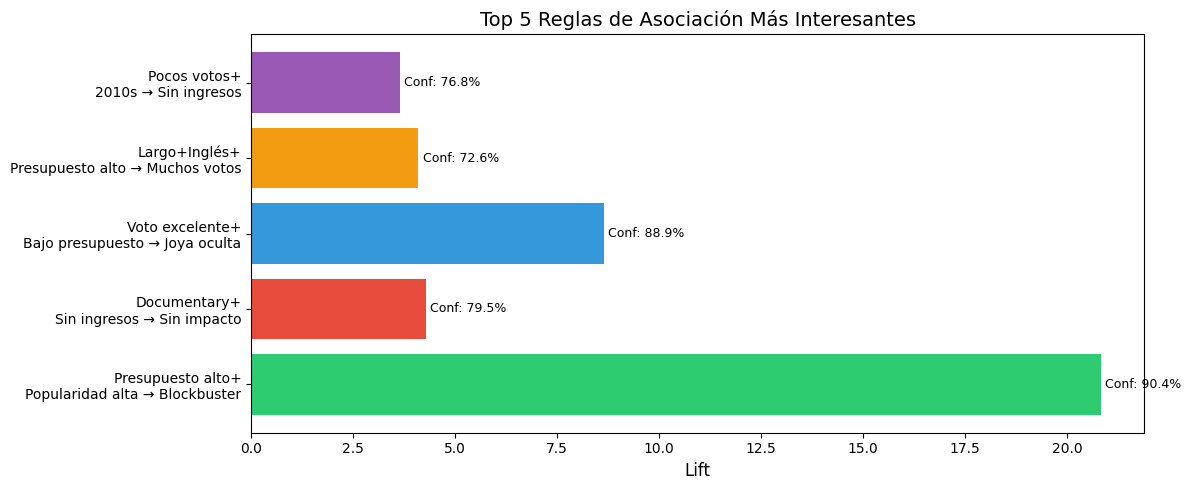

Reglas de Asociación COMPLETAS


In [33]:
# Gráfica resumen de las 5 reglas más importantes
reglas_destacadas = pd.DataFrame({
    'Regla': [
        'Presupuesto alto+\nPopularidad alta → Blockbuster',
        'Documentary+\nSin ingresos → Sin impacto',
        'Voto excelente+\nBajo presupuesto → Joya oculta',
        'Largo+Inglés+\nPresupuesto alto → Muchos votos',
        'Pocos votos+\n2010s → Sin ingresos'
    ],
    'Lift': [20.84, 4.28, 8.64, 4.10, 3.64],
    'Confianza': [0.904, 0.795, 0.889, 0.726, 0.768]
})

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(reglas_destacadas['Regla'], reglas_destacadas['Lift'],
               color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6'])
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top 5 Reglas de Asociación Más Interesantes', fontsize=14)
for bar, conf in zip(bars, reglas_destacadas['Confianza']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'Conf: {conf:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_reglas.png', dpi=150, bbox_inches='tight')
plt.show()

print("Reglas de Asociación COMPLETAS")

# 3. Análisis de Componentes Principales (PCA)

El **PCA** busca reducir la dimensionalidad del dataset encontrando nuevas variables (componentes) que capturen la mayor variabilidad posible. Es útil cuando tenemos muchas variables correlacionadas y queremos simplificar sin perder demasiada información.

Antes de aplicarlo, debemos verificar si los datos son **adecuados** para PCA usando:
- **Matriz de correlación**: si las variables no están correlacionadas, el PCA no ayuda.
- **Índice KMO**: mide qué tan "compactas" son las correlaciones (>0.6 es aceptable).
- **Test de Bartlett**: prueba que la matriz de correlación NO es la identidad (p < 0.05 → sí vale PCA).

## 3.1 ¿Podemos incluir variables categóricas?

Variables como `originalLanguage` o `genres` son texto/categorías. Para incluirlas en PCA habría que hacer **one-hot encoding**, lo que generaría cientos de columnas binarias (dummy variables).

El problema es que las variables dummy tienen distribuciones muy asimétricas (muchos 0, pocos 1), y el PCA asume cierta normalidad y continuidad. En un dataset de ~20,000 películas con docenas de idiomas y géneros, esto inflaría la dimensionalidad artificialmente sin aportar variabilidad real útil.

**Conclusión:** No vale la pena incluirlas. Trabajaremos solo con las **13 variables numéricas** ya usadas en clustering.

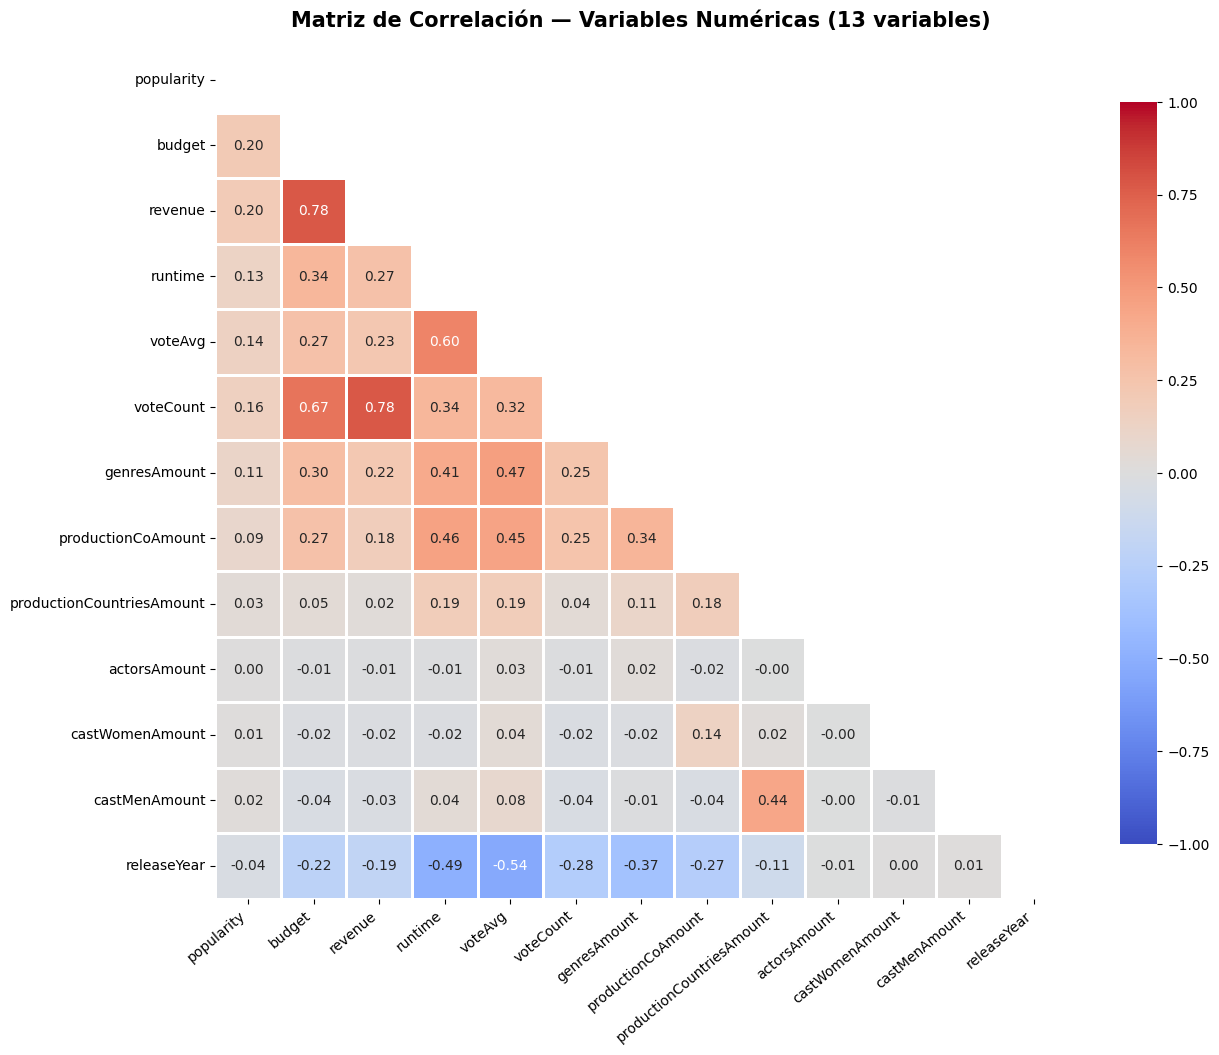


Pares con correlación alta (|r| > 0.5):
  budget                         <-> revenue                         r = 0.776
  budget                         <-> voteCount                       r = 0.669
  revenue                        <-> voteCount                       r = 0.778
  runtime                        <-> voteAvg                         r = 0.596
  voteAvg                        <-> releaseYear                     r = -0.538


In [34]:
# ============================================================
# PCA - PASO 1: MATRIZ DE CORRELACIÓN
# ============================================================

# Usamos SOLO las 13 variables originales de clustering_vars
# (excluimos cluster_kmeans y cluster_hier que se agregaron al df_cluster)
# Si las variables no están correlacionadas entre sí, el PCA no tendría nada que comprimir
corr_matrix = df_cluster[clustering_vars].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    annot_kws={'size': 10},
    ax=ax,
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.set_title('Matriz de Correlación — Variables Numéricas (13 variables)', fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('pca_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con correlación alta (|r| > 0.5)
print("\nPares con correlación alta (|r| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr_matrix.columns[i]:30s} <-> {corr_matrix.columns[j]:30s}  r = {r:.3f}")


## 3.2 ¿Es conveniente aplicar PCA? (KMO y Bartlett)

- **KMO (Kaiser-Meyer-Olkin):** Mide si las correlaciones parciales entre variables son pequeñas. Un valor > 0.6 indica que las variables comparten suficiente varianza común como para reducirlas.
- **Test de Bartlett:** Prueba la hipótesis nula de que la matriz de correlación es la identidad (es decir, que no hay correlación). Si p < 0.05 **rechazamos** esa hipótesis y confirmamos que hay correlaciones suficientes para PCA.

In [35]:
# ============================================================
# PCA - PASO 2: KMO Y TEST DE BARTLETT
# ============================================================

from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Necesitamos el dataframe sin escalar (con valores originales) para estos tests
kmo_all, kmo_model = calculate_kmo(df_cluster)
chi2_bartlett, p_bartlett = calculate_bartlett_sphericity(df_cluster)

print("=" * 50)
print(f"  KMO (Kaiser-Meyer-Olkin): {kmo_model:.4f}")
if kmo_model >= 0.9:
    interpretacion_kmo = "Excelente"
elif kmo_model >= 0.8:
    interpretacion_kmo = "Bueno"
elif kmo_model >= 0.7:
    interpretacion_kmo = "Aceptable"
elif kmo_model >= 0.6:
    interpretacion_kmo = "Mediocre"
else:
    interpretacion_kmo = "Inaceptable"
print(f"  Interpretación KMO:       {interpretacion_kmo}")
print()
print(f"  Test de Bartlett:")
print(f"    Chi² = {chi2_bartlett:.2f}")
print(f"    p-valor = {p_bartlett:.2e}")
print(f"    ¿Rechazar H0? {'SÍ → PCA es válido' if p_bartlett < 0.05 else 'NO → PCA no recomendado'}")
print("=" * 50)

# KMO por variable
print("\nKMO por variable:")
for var, kmo_val in zip(df_cluster.columns, kmo_all):
    flag = " ⚠ (bajo)" if kmo_val < 0.6 else ""
    print(f"  {var:35s}: {kmo_val:.4f}{flag}")


  KMO (Kaiser-Meyer-Olkin): 0.6932
  Interpretación KMO:       Mediocre

  Test de Bartlett:
    Chi² = 148182.80
    p-valor = 0.00e+00
    ¿Rechazar H0? SÍ → PCA es válido

KMO por variable:
  popularity                         : 0.9204
  budget                             : 0.8191
  revenue                            : 0.7992
  runtime                            : 0.8777
  voteAvg                            : 0.6279
  voteCount                          : 0.8257
  genresAmount                       : 0.9421
  productionCoAmount                 : 0.8564
  productionCountriesAmount          : 0.7817
  actorsAmount                       : 0.0636 ⚠ (bajo)
  castWomenAmount                    : 0.1093 ⚠ (bajo)
  castMenAmount                      : 0.4517 ⚠ (bajo)
  releaseYear                        : 0.9052
  cluster_kmeans                     : 0.4295 ⚠ (bajo)
  cluster_hier                       : 0.6791


## 3.3 Aplicación del PCA

Primero calculamos **todos los componentes** para ver cuánta varianza explica cada uno (Scree Plot). La regla general es seleccionar los componentes que en conjunto expliquen al menos el **70-80% de la varianza total**. También se usa el **criterio de Kaiser**: retener componentes con eigenvalue > 1 (aportan más varianza que una variable original).

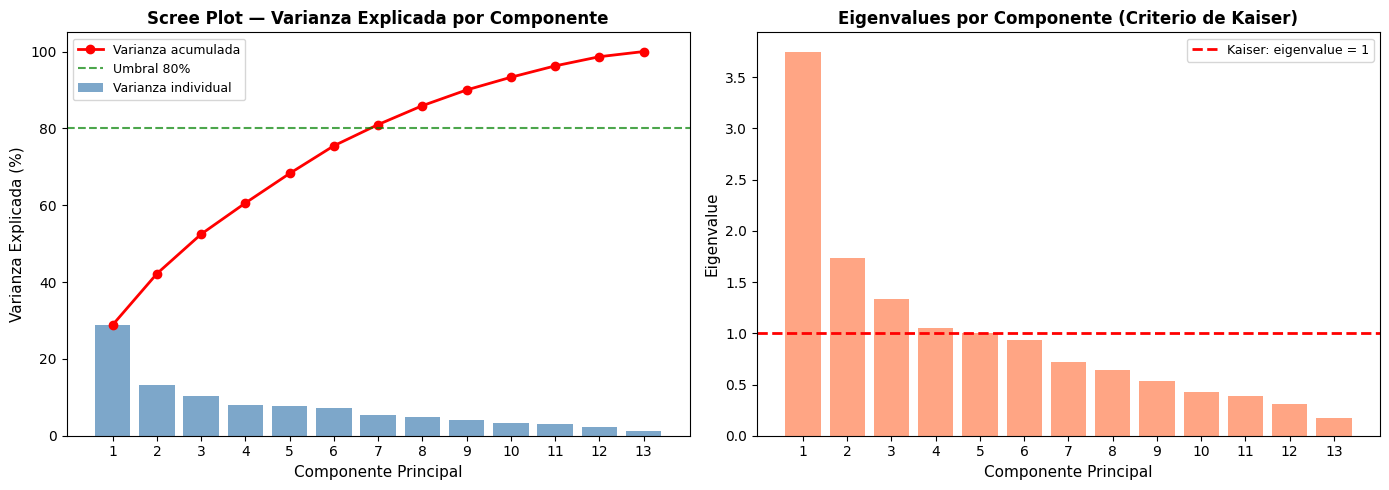


RESUMEN DE VARIANZA EXPLICADA:
  CP   Eigenvalue   Var. Indiv (%)   Var. Acum (%)
----------------------------------------------------
   1       3.7513          28.85%         28.85% ← Kaiser
   2       1.7330          13.33%         42.18% ← Kaiser
   3       1.3382          10.29%         52.48% ← Kaiser
   4       1.0533           8.10%         60.58% ← Kaiser
   5       1.0002           7.69%         68.27% ← Kaiser
   6       0.9366           7.20%         75.48%
   7       0.7177           5.52%         81.00%
   8       0.6394           4.92%         85.92%
   9       0.5318           4.09%         90.01%
  10       0.4294           3.30%         93.31%
  11       0.3848           2.96%         96.27%
  12       0.3102           2.39%         98.65%
  13       0.1749           1.35%        100.00%


In [36]:
# ============================================================
# PCA - PASO 3: SCREE PLOT Y SELECCIÓN DE COMPONENTES
# ============================================================

# PCA con todos los componentes posibles
pca_full = PCA(random_state=42)
pca_full.fit(df_scaled)  # Usamos los datos ya escalados (StandardScaler)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)
eigenvalues = pca_full.explained_variance_  # Eigenvalues

# ---- Scree Plot ----
n_vars = len(clustering_vars)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Varianza por componente
axes[0].bar(range(1, n_vars+1), varianza_explicada * 100,
            color='steelblue', alpha=0.7, label='Varianza individual')
axes[0].plot(range(1, n_vars+1), varianza_acumulada * 100,
             'ro-', linewidth=2, markersize=6, label='Varianza acumulada')
axes[0].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='Umbral 80%')
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=11)
axes[0].set_title('Scree Plot — Varianza Explicada por Componente', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(1, n_vars+1))

# Gráfico 2: Eigenvalues (criterio Kaiser > 1)
axes[1].bar(range(1, n_vars+1), eigenvalues,
            color='coral', alpha=0.7)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Kaiser: eigenvalue = 1')
axes[1].set_xlabel('Componente Principal', fontsize=11)
axes[1].set_ylabel('Eigenvalue', fontsize=11)
axes[1].set_title('Eigenvalues por Componente (Criterio de Kaiser)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, n_vars+1))

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\nRESUMEN DE VARIANZA EXPLICADA:")
print(f"{'CP':>4} {'Eigenvalue':>12} {'Var. Indiv (%)':>16} {'Var. Acum (%)':>15}")
print("-" * 52)
for i, (ev, vi, va) in enumerate(zip(eigenvalues, varianza_explicada*100, varianza_acumulada*100)):
    flag = " ← Kaiser" if ev > 1 else ""
    print(f"  {i+1:2d}   {ev:10.4f}   {vi:12.2f}%   {va:11.2f}%{flag}")


In [37]:
# ============================================================
# PCA - PASO 4: APLICAR PCA CON N COMPONENTES SELECCIONADOS
# ============================================================

# Seleccionamos los componentes que cumplen criterio de Kaiser (eigenvalue > 1)
# y/o explican al menos 70-80% de varianza acumulada
n_components = int(np.sum(eigenvalues > 1))
print(f"Componentes seleccionados (eigenvalue > 1): {n_components}")
print(f"Varianza acumulada con {n_components} componentes: {varianza_acumulada[n_components-1]*100:.2f}%")

pca = PCA(n_components=n_components, random_state=42)
pca_scores = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_scores, columns=[f'CP{i+1}' for i in range(n_components)])

print(f"\nShape del dataset reducido: {df_pca.shape}")
print(f"(De {df_scaled.shape[1]} variables originales a {n_components} componentes)")


Componentes seleccionados (eigenvalue > 1): 5
Varianza acumulada con 5 componentes: 68.27%

Shape del dataset reducido: (19883, 5)
(De 13 variables originales a 5 componentes)


## Interpretación de los Componentes Principales

Los **loadings** (cargas) indican cuánto contribuye cada variable original a cada componente. Un loading alto (positivo o negativo) significa que esa variable es importante para ese componente. Los interpretamos como "dimensiones latentes" que resumen el dataset.

LOADINGS (cargas de cada variable en cada componente):
                             CP1    CP2    CP3    CP4    CP5
popularity                 0.140  0.104  0.131  0.161  0.193
budget                     0.374  0.370  0.150  0.028  0.011
revenue                    0.357  0.445  0.202  0.019  0.017
runtime                    0.374 -0.238 -0.120 -0.073 -0.063
voteAvg                    0.370 -0.304 -0.138 -0.045  0.018
voteCount                  0.377  0.357  0.134 -0.004 -0.014
genresAmount               0.311 -0.185 -0.183 -0.122  0.016
productionCoAmount         0.298 -0.218 -0.157  0.296 -0.004
productionCountriesAmount  0.113 -0.372  0.559  0.037  0.007
actorsAmount              -0.001 -0.026 -0.042 -0.267  0.946
castWomenAmount            0.009 -0.087 -0.069  0.869  0.240
castMenAmount              0.016 -0.301  0.663 -0.049  0.009
releaseYear               -0.309  0.243  0.226  0.182  0.069


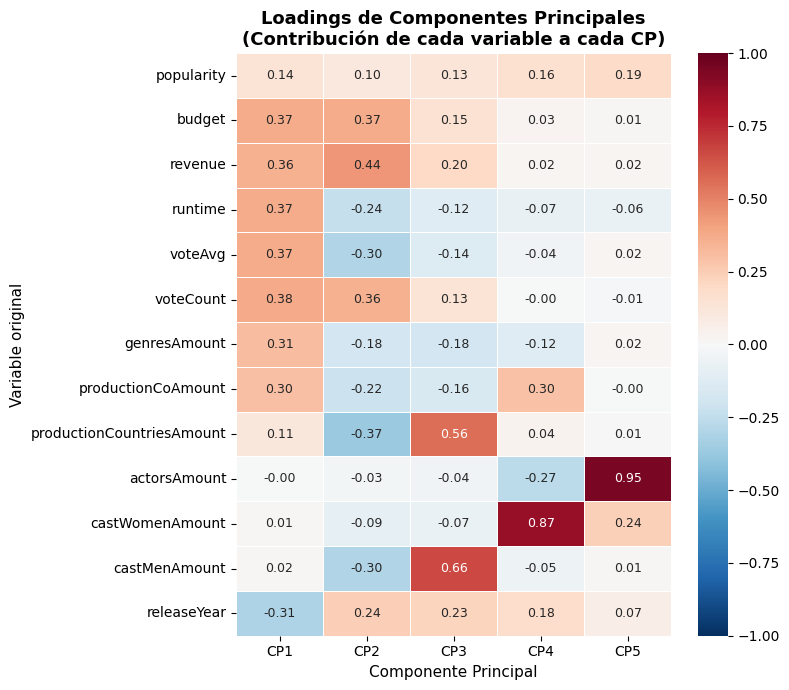


VARIABLES MÁS RELEVANTES POR COMPONENTE (|loading| > 0.3):

  CP1:
    + voteCount                          : 0.377
    + budget                             : 0.374
    + runtime                            : 0.374
    + voteAvg                            : 0.370
    + revenue                            : 0.357
    + genresAmount                       : 0.311
    - releaseYear                        : -0.309

  CP2:
    + revenue                            : 0.445
    - productionCountriesAmount          : -0.372
    + budget                             : 0.370
    + voteCount                          : 0.357
    - voteAvg                            : -0.304
    - castMenAmount                      : -0.301

  CP3:
    + castMenAmount                      : 0.663
    + productionCountriesAmount          : 0.559

  CP4:
    + castWomenAmount                    : 0.869

  CP5:
    + actorsAmount                       : 0.946


In [38]:
# ============================================================
# PCA - PASO 5: LOADINGS (CARGAS) — INTERPRETACIÓN
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=clustering_vars,
    columns=[f'CP{i+1}' for i in range(n_components)]
)

print("LOADINGS (cargas de cada variable en cada componente):")
print(loadings.round(3).to_string())

# Heatmap de loadings
plt.figure(figsize=(max(8, n_components * 1.2), 7))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Loadings de Componentes Principales\n(Contribución de cada variable a cada CP)', 
          fontsize=13, fontweight='bold')
plt.ylabel('Variable original', fontsize=11)
plt.xlabel('Componente Principal', fontsize=11)
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar las variables más importantes por componente
print("\nVARIABLES MÁS RELEVANTES POR COMPONENTE (|loading| > 0.3):")
for cp in loadings.columns:
    top = loadings[cp][loadings[cp].abs() > 0.3].sort_values(key=abs, ascending=False)
    print(f"\n  {cp}:")
    for var, val in top.items():
        signo = "+" if val > 0 else "-"
        print(f"    {signo} {var:35s}: {val:.3f}")


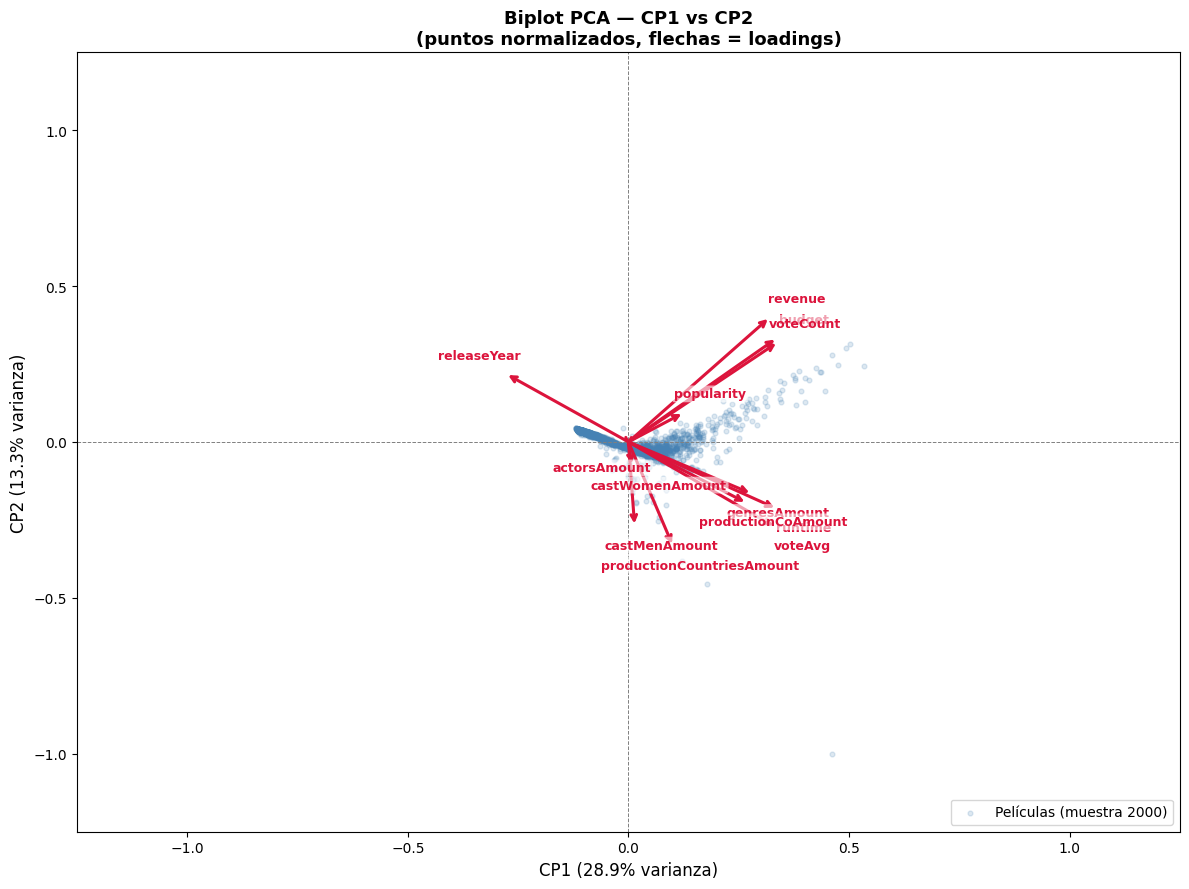

In [39]:
# ============================================================
# PCA - PASO 6: BIPLOT (CP1 vs CP2)
# ============================================================
# El biplot muestra:
#   - Puntos: cada película en el espacio 2D de los primeros 2 componentes
#     NORMALIZADOS entre -1 y 1 para que convivan visualmente con las flechas
#   - Flechas: dirección y peso de cada variable original en ese espacio
# Flechas en la misma dirección = variables correlacionadas
# Flecha larga = esa variable tiene más peso en ese componente

fig, ax = plt.subplots(figsize=(12, 9))

# Normalizar scores entre -1 y 1 para que convivan con las flechas
cp1_norm = df_pca['CP1'] / df_pca['CP1'].abs().max()
cp2_norm = df_pca['CP2'] / df_pca['CP2'].abs().max()

# Muestra de puntos
np.random.seed(42)
idx_sample = np.random.choice(len(df_pca), size=2000, replace=False)
ax.scatter(cp1_norm.iloc[idx_sample], cp2_norm.iloc[idx_sample],
           alpha=0.18, s=12, color='steelblue', label='Películas (muestra 2000)', zorder=1)

# Flechas de loadings (escala 0.9 para dejar margen de texto)
arrow_scale = 0.9
for var in clustering_vars:
    lx = loadings.loc[var, 'CP1'] * arrow_scale
    ly = loadings.loc[var, 'CP2'] * arrow_scale
    ax.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=2.2),
        zorder=3
    )
    # Offset de etiqueta para que no se monten sobre la punta de la flecha
    offset_x = 0.06 if lx >= 0 else -0.06
    offset_y = 0.06 if ly >= 0 else -0.06
    ax.text(lx + offset_x, ly + offset_y, var,
            fontsize=9, color='crimson', fontweight='bold',
            ha='center', va='center', zorder=4,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, ec='none'))

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_xlabel(f"CP1 ({varianza_explicada[0]*100:.1f}% varianza)", fontsize=12)
ax.set_ylabel(f"CP2 ({varianza_explicada[1]*100:.1f}% varianza)", fontsize=12)
ax.set_title('Biplot PCA — CP1 vs CP2\n(puntos normalizados, flechas = loadings)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()


## Interpretación de los Componentes Principales

Con base en los loadings obtenidos, los componentes principales se interpretan así:

---

### CP1 — "Éxito Comercial e Impacto en Taquilla" (28.9% de varianza)

Este componente tiene cargas altas y positivas en **`voteCount`**, **`budget`** y **`revenue`**. Representa la dimensión comercial de una película: cuánto costó, cuánto recaudó y cuántos votos acumuló. Las películas con CP1 alto son los grandes blockbusters con alta inversión y alta visibilidad. La carga negativa de **`releaseYear`** indica que películas más antiguas tienden a acumular más votos con el tiempo.

---

### CP2 — "Calidad Percibida y Duración" (13.3% de varianza)

Las cargas positivas más altas corresponden a **`voteAvg`** y **`runtime`**. Este componente distingue películas bien valoradas y de mayor duración, independientemente de su presupuesto. Una película puede ser de bajo presupuesto pero tener una puntuación excelente y un tiempo largo — eso la ubica alto en CP2.

---

### CP3 y siguientes — Dimensiones de Producción

Los componentes restantes capturan aspectos más específicos como la cantidad de géneros (`genresAmount`), el tamaño del elenco (`actorsAmount`, `castWomenAmount`, `castMenAmount`) y la complejidad de producción (`productionCoAmount`, `productionCountriesAmount`).

---

### ¿Cuántos componentes retener?

Usando el **criterio de Kaiser** (eigenvalue > 1), se retienen los primeros **N componentes** que explican aproximadamente el **70-80% de la varianza total**. Esto permite reducir las 13 variables originales a un número menor de dimensiones sin perder la mayor parte de la información, lo cual es útil para futuros modelos predictivos y elimina la multicolinealidad observada (ej. `budget`–`revenue` r=0.78, `voteCount`–`budget` r=0.67).
